## Импорт библиотек

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## Загрузка данных

In [4]:
df = pd.read_csv('car_sales_data.csv')

In [5]:
df.head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  object 
 1   Model                50000 non-null  object 
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  object 
 4   Year of manufacture  50000 non-null  int64  
 5   Mileage              50000 non-null  int64  
 6   Price                50000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 2.7+ MB


In [7]:
df.duplicated().sum()

12

In [8]:
df.drop_duplicates(inplace=True)

Данные содержат следующие столбцы:
- __Manufacturer__ (Производитель): Марка или компания, производящая автомобиль.
- __Model__ (Модель): Конкретная модель автомобиля.
- __Engine size__ (Объем двигателя): Объем двигателя в литрах.
- __Fuel type__ (Тип топлива): Тип топлива, используемого автомобилем (бензин, дизель, гибрид, электромобиль).
- __Year of manufacture__ (Год выпуска): Год выпуска автомобиля.
- __Mileage__ (Пробег): Общее расстояние, пройденное автомобилем, измеренное в милях.
- __Price__ (Цена): Цена продажи автомобиля в фунтах стерлингов (приблизительные значения).


In [10]:
df.describe()

,Engine size,Year of manufacture,Mileage,Price
count,49988.000000,49988.000000,49988.000000,49988.000000
mean,1.773140,2004.209630,112515.561215,13829.112387
std,0.734149,9.646056,71624.341062,16417.812203
min,1.000000,1984.000000,630.000000,76.000000
25%,1.400000,1996.000000,54375.250000,3059.750000
50%,1.600000,2004.000000,101011.500000,7971.000000
75%,2.000000,2012.000000,158617.250000,19028.500000
max,5.000000,2022.000000,453537.000000,168081.000000


array([[<Axes: title={'center': 'Engine size'}>,
        <Axes: title={'center': 'Year of manufacture'}>],
       [<Axes: title={'center': 'Mileage'}>,
        <Axes: title={'center': 'Price'}>]], dtype=object)

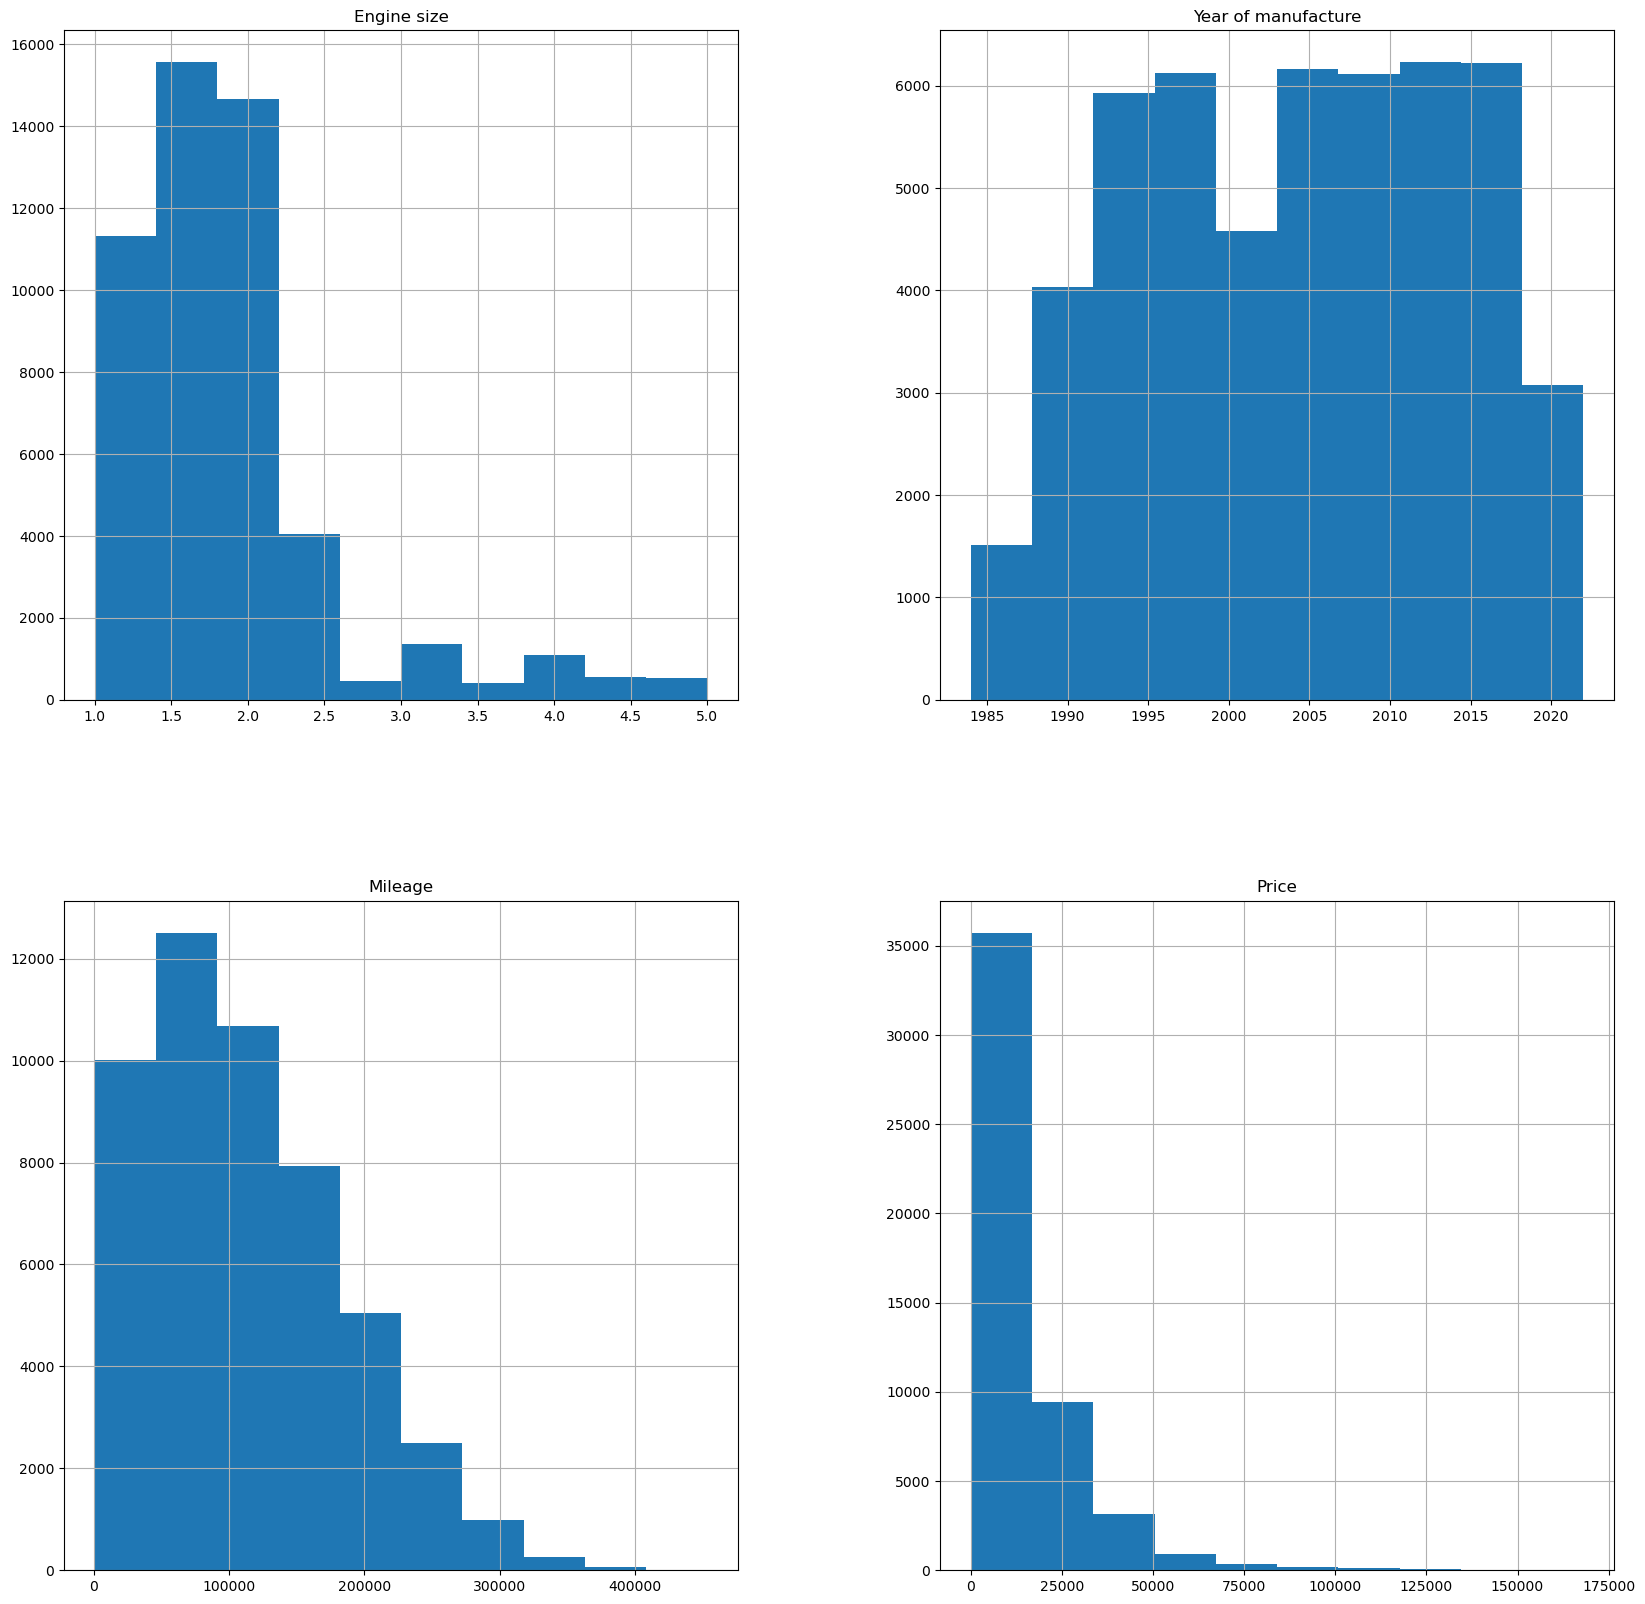

In [11]:
df.hist(figsize=(20,20))

<Figure size 800x600 with 0 Axes>

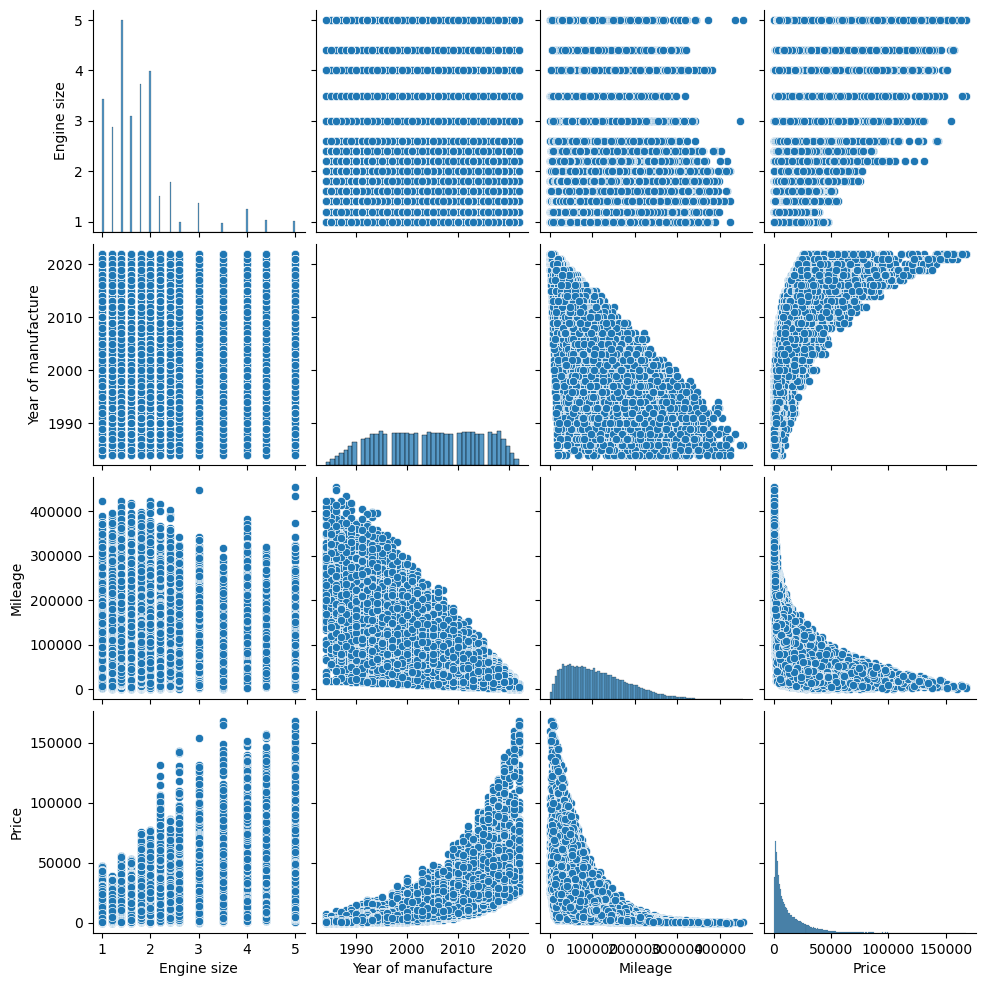

In [12]:
plt.figure(figsize=(8,6))
sns.pairplot(df)

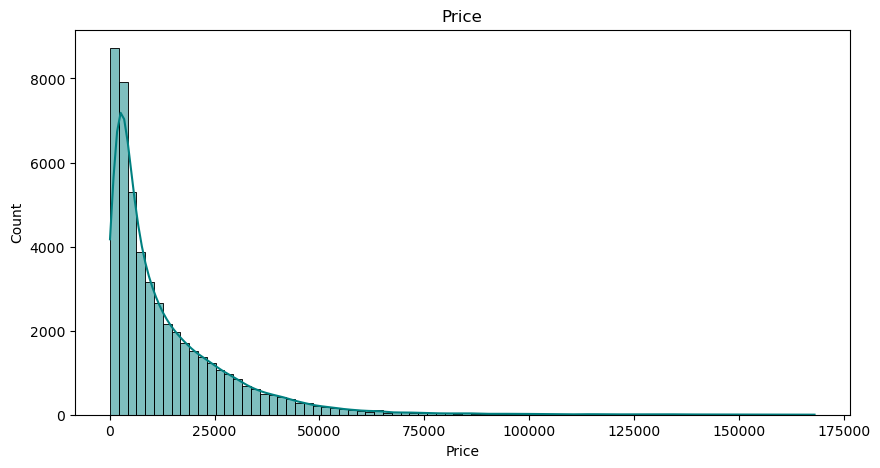

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(df['Price'], bins=80, kde=True, color='teal')
plt.title('Price')
plt.show()

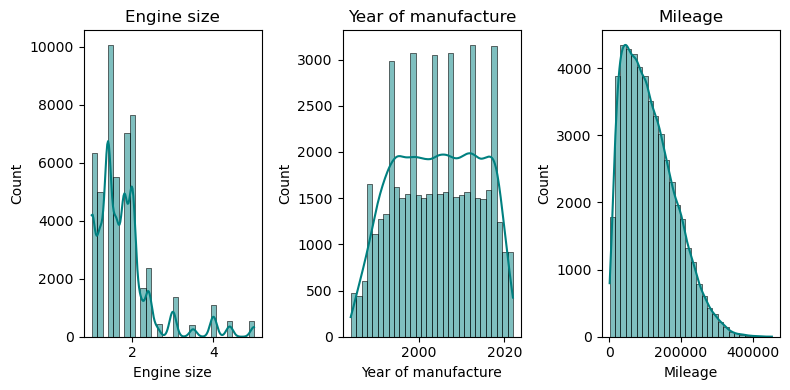

In [14]:
cols = ['Engine size','Year of manufacture','Mileage']
plt.figure(figsize=(8,4))
for col in cols:
    plt.subplot(1,3,cols.index(col)+1)
    sns.histplot(df[col],bins=30,kde=True,color='teal')
    plt.title(col)
plt.tight_layout()

## Обучение

In [16]:
df['CarAge'] = 2026 - df['Year of manufacture']
df.drop(columns=['Year of manufacture'],inplace=True)

Year of manufacture удаляем чтобы возраст был важнее года выпуска

In [17]:
numeric_cols = ['Mileage','CarAge']

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [18]:
df = pd.get_dummies(df,columns=['Model'],drop_first=True,dtype=int)

In [19]:
manufacturer = {
    'VW': 0,
    'Ford': 1,
    'Toyota': 2,
    'BMW': 3,
    'Porsche': 4,
}
df['Manufacturer'] = df['Manufacturer'].map(manufacturer)

In [20]:
fuel = {
    'Diesel': 0,
    'Petrol': 1,
    'Hybrid': 2
}
df['Fuel type'] = df['Fuel type'].map(fuel)

In [21]:
X = df.drop('Price',axis=1)
y = df['Price']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

### Линейная регрессия

In [24]:
lr_model = LinearRegression()
lr_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
y_pred_lr = lr_model.predict(X_test)

In [26]:
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

In [27]:
print('Linear Regression:')
print(f'R2 Score: {lr_r2:.4f}')
print(f'MAE: {lr_mae:.2f}')
print(f'RMSE: {lr_rmse:.2f}')

Linear Regression:
R2 Score: 0.7142
MAE: 5737.31
RMSE: 8715.52


### Random Forest Regressor

In [29]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [30]:
rf_r2_score = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test,y_pred_rf))

print('Random Forest Regression:')
print(f'R2 Score: {rf_r2_score:.4f}')
print(f'MAE: {rf_mae:.2f}')
print(f'RMSE: {rf_rmse:.2f}')

Random Forest Regression:
R2 Score: 0.9984
MAE: 291.88
RMSE: 659.48


### Нейронная модель

In [32]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)


X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=101
)

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

X_val_scaled = scaler_X.transform(X_val)
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1)).flatten()




масштабируем для приведения признаков к единому диапазону или распределению

In [34]:
input_shape = X_train_scaled.shape[1]

nn_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(input_shape,)),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

nn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = nn_model.fit(
    X_train_scaled, y_train_scaled,
    validation_split=0.15,
    epochs=40,
    batch_size=512,
    verbose=1,
    callbacks=[keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)]
)

Epoch 1/40
47/47 [==============================] - 1s 4ms/step - loss: 0.4043 - mae: 0.4005 - val_loss: 0.4479 - val_mae: 0.4646
Epoch 2/40
47/47 [==============================] - 0s 2ms/step - loss: 0.1007 - mae: 0.2069 - val_loss: 0.3273 - val_mae: 0.4049
Epoch 3/40
47/47 [==============================] - 0s 2ms/step - loss: 0.0741 - mae: 0.1741 - val_loss: 0.2427 - val_mae: 0.3508
Epoch 4/40
47/47 [==============================] - 0s 2ms/step - loss: 0.0545 - mae: 0.1528 - val_loss: 0.1899 - val_mae: 0.3119
Epoch 5/40
47/47 [==============================] - 0s 2ms/step - loss: 0.0454 - mae: 0.1378 - val_loss: 0.1349 - val_mae: 0.2653
Epoch 6/40
47/47 [==============================] - 0s 2ms/step - loss: 0.0396 - mae: 0.1279 - val_loss: 0.0968 - val_mae: 0.2174
Epoch 7/40
47/47 [==============================] - 0s 2ms/step - loss: 0.0381 - mae: 0.1222 - val_loss: 0.0521 - val_mae: 0.1650
Epoch 8/40
47/47 [==============================] - 0s 2ms/step - loss: 0.0348 - mae: 0.11

In [35]:
y_pred_scaled = nn_model.predict(X_test_scaled).flatten()

y_pred_scaled

array([-0.5532762 , -0.6225779 , -0.72418875, ..., -0.18281305,
       -0.29830718, -0.52789384], dtype=float32)

In [36]:
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test_original = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

In [37]:
nn_pred = nn_model.predict(X_train_scaled, verbose=0).flatten()

In [38]:
nn_mae = mean_absolute_error(y_test, y_pred)
nn_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
nn_r2 = r2_score(y_test, y_pred)

print('Neural model:')
print(f'R2 Score: {nn_r2:.4f}')
print(f'MAE: {nn_mae:.2f}')
print(f'RMSE: {nn_rmse:.2f}')

Neural model:
R2 Score: 0.9933
MAE: 1013.03
RMSE: 1316.65


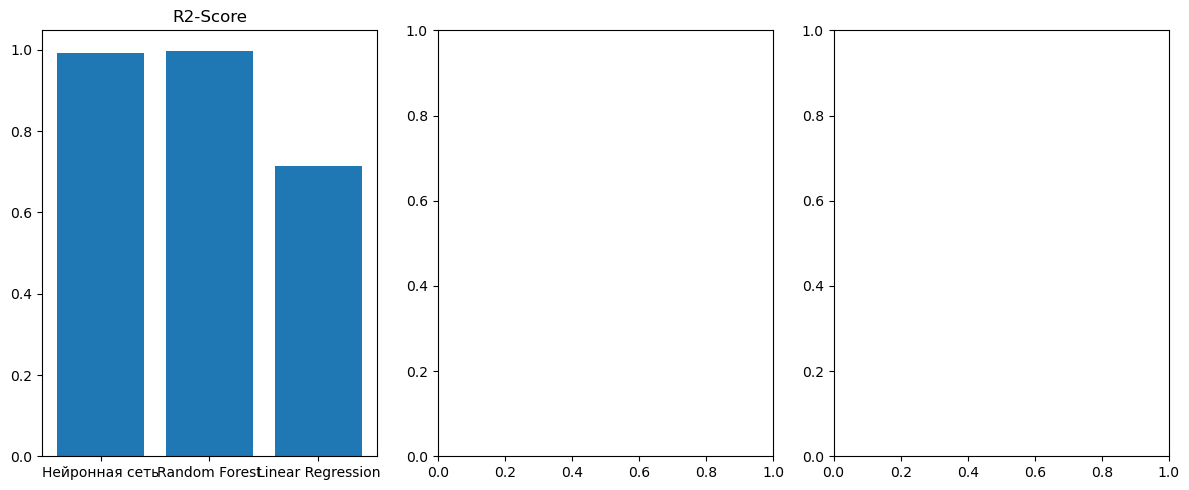

In [39]:
results = {
    'Нейронная сеть': {
        'r2': nn_r2
    },
    'Random Forest': {
        'r2': rf_r2_score
    },
    'Linear Regression': {
        'r2': lr_r2
    }
}

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# r2
r2_list = [results[model]['r2'] for model in results.keys()]
axes[0].bar(results.keys(), r2_list,)
axes[0].set_title('R2-Score')


plt.tight_layout()
plt.show()

## Вывод:

Этот проект успешно демонстрирует практическое применение машинного обучения для прогнозирования цен на подержанные автомобили со значительной точностью. Разработанная модель эффективно отражает сложные взаимосвязи между техническими характеристиками автомобиля и рыночной стоимостью, при этом ключевые факторы включают возраст автомобиля, пробег, марку производителя и характеристики двигателя. Внедрение функционального инжиниринга — создание новых переменных, таких как возраст автомобиля, годовой пробег и флаги люксовых брендов, — оказалось решающим фактором повышения производительности модели и ее интерпретируемости.

Random Forest Regressor показал лучший R² (0.9984).